# 기본 모듈 로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 가져오기

In [3]:
data = pd.read_csv('WA.csv')

In [6]:
pd.set_option('display.max_columns', None)
data.head(3)

,나이,회사와의마찰,출장,일당,부서,거리,학력,전공,사번,만족도,성별,시급,참여프로젝트,근속연차,직급,직업만족도,결혼여부,월급,이직회수,성인여부,야근,업무평가,주변평가,근무기준시간,스톡옵션레벨,경력,전년도교육출장횟수,워라밸,현회사근속년수
0,41,Yes,1~29회,1102,영업,1,2,사회과학계열,1,2,Female,94,3,2,영업직,4,Single,5993,8,Y,Yes,보통,1,80,0,8,0,1,6
1,49,No,30회 이상,279,R&D,8,1,사회과학계열,2,3,Male,61,2,2,연구직,2,Married,5130,1,Y,No,좋다,4,80,1,10,3,3,10
2,37,Yes,1~29회,1373,R&D,2,2,기타,4,4,Male,92,2,1,엔지니어,3,Single,2090,6,Y,Yes,보통,2,80,0,7,3,3,0


# 결측치 확인

In [18]:
print(data.info())
print(data.isnull().sum())
print(data.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 29 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   나이         1470 non-null   int64 
 1   회사와의마찰     1470 non-null   object
 2   출장         1470 non-null   object
 3   일당         1470 non-null   int64 
 4   부서         1470 non-null   object
 5   거리         1470 non-null   int64 
 6   학력         1470 non-null   int64 
 7   전공         1470 non-null   object
 8   사번         1470 non-null   int64 
 9   만족도        1470 non-null   int64 
 10  성별         1470 non-null   object
 11  시급         1470 non-null   int64 
 12  참여프로젝트     1470 non-null   int64 
 13  근속연차       1470 non-null   int64 
 14  직급         1470 non-null   object
 15  직업만족도      1470 non-null   int64 
 16  결혼여부       1470 non-null   object
 17  월급         1470 non-null   int64 
 18  이직회수       1470 non-null   int64 
 19  성인여부       1470 non-null   object
 20  야근         1470 non-null   obj

# 컬럼 확인

In [48]:
data.columns

Index(['나이', '회사와의마찰', '출장', '일당', '부서', '거리', '학력', '전공', '사번', '만족도', '성별',
       '시급', '참여프로젝트', '근속연차', '직급', '직업만족도', '결혼여부', '월급', '이직회수', '성인여부',
       '야근', '업무평가', '주변평가', '근무기준시간', '스톡옵션레벨', '경력', '전년도교육출장횟수', '워라밸',
       '현회사근속년수'],
      dtype='object')

# X,y 컬럼 조정
- 타겟 변수에 알맞은 학습 데이터 전처리

In [49]:
df_Xy = data[['나이','출장','학력','참여프로젝트','근속연차','이직회수','야근','스톡옵션레벨','경력','전년도교육출장횟수','현회사근속년수','업무평가']]
df_Xy.info(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   나이         1470 non-null   int64 
 1   출장         1470 non-null   object
 2   학력         1470 non-null   int64 
 3   참여프로젝트     1470 non-null   int64 
 4   근속연차       1470 non-null   int64 
 5   이직회수       1470 non-null   int64 
 6   야근         1470 non-null   object
 7   스톡옵션레벨     1470 non-null   int64 
 8   경력         1470 non-null   int64 
 9   전년도교육출장횟수  1470 non-null   int64 
 10  현회사근속년수    1470 non-null   int64 
 11  업무평가       1470 non-null   object
dtypes: int64(9), object(3)
memory usage: 137.9+ KB


# 원핫인코딩 필요 컬럼 구분
- objects 확인 (출장, 야근)

In [64]:
X = data[['나이','출장','학력','참여프로젝트','근속연차','이직회수','야근','스톡옵션레벨','경력','전년도교육출장횟수','현회사근속년수']]
X.head(1)

,나이,출장,학력,참여프로젝트,근속연차,이직회수,야근,스톡옵션레벨,경력,전년도교육출장횟수,현회사근속년수
0,41,1~29회,2,3,2,8,Yes,0,8,0,6


In [51]:
y = data['업무평가']
y.sample()

466    보통
Name: 업무평가, dtype: object

In [52]:
print(X.shape, y.shape)

(1470, 11) (1470,)


In [65]:
X_one = pd.get_dummies(X, columns=['출장','야근'], drop_first=False)
X_one.head(2)

,나이,학력,참여프로젝트,근속연차,이직회수,스톡옵션레벨,경력,전년도교육출장횟수,현회사근속년수,출장_0회,출장_1~29회,출장_30회 이상,야근_No,야근_Yes
0,41,2,3,2,8,0,8,0,6,False,True,False,False,True
1,49,1,2,2,1,1,10,3,10,False,False,True,True,False


# y값 라벨인코딩

In [66]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_label = le.fit_transform(data['업무평가'])

In [67]:
y_label

array([0, 1, 0, ..., 1, 0, 0], shape=(1470,))

# 학습용 데이터셋 분할

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X_one, y_label, 
                                                    test_size=0.2,
                                                    stratify=y_label,
                                                    random_state=42)

In [69]:
print('y_train :',np.bincount(y_train))
print('y_test : ', np.bincount(y_test))

y_train : [995 181]
y_test :  [249  45]


# 모델 생성

In [70]:
from xgboost import XGBClassifier
model = XGBClassifier(random_state=42,
                      eval_metric='mlogloss',)

In [71]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# 예측값, 정확도

In [72]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8333333333333334


In [73]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.86      0.96      0.91       249\n           1       0.36      0.11      0.17        45\n\n    accuracy                           0.83       294\n   macro avg       0.61      0.54      0.54       294\nweighted avg       0.78      0.83      0.79       294\n'

# 컨퓨전매트릭스

In [74]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[240   9]
 [ 40   5]]


# 특성 중요도

In [75]:
feature_importance = model.feature_importances_
feature_names = X_one.columns

In [76]:
importance_df = pd.DataFrame({'feature': feature_names,'importance': feature_importance}).sort_values('importance', ascending=False)
print(importance_df.head(10))

      feature  importance
10   출장_1~29회    0.105421
12      야근_No    0.092288
9       출장_0회    0.084909
3        근속연차    0.080412
4        이직회수    0.077885
2      참여프로젝트    0.072808
1          학력    0.072440
6          경력    0.071914
0          나이    0.071698
7   전년도교육출장횟수    0.070549


# 오답률 조정 시작
- 해당 전체 코드

# 가중치 계산 적용
- 쓸모없음

In [78]:
class_counts = np.bincount(y_train)
total_samples = len(y_train)
class_weights = total_samples / (len(class_counts) * class_counts)
print(class_weights)

[0.59095477 3.24861878]


In [79]:
scale_pos_weight = class_counts[0] / class_counts[1] if len(class_counts) > 1 else 1
print(f"   scale_pos_weight: {scale_pos_weight:.2f}")

   scale_pos_weight: 5.50


In [252]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

data = pd.read_csv('WA.csv')

df_Xy = data[['나이','출장','학력','참여프로젝트','근속연차','이직회수','야근','스톡옵션레벨','경력','전년도교육출장횟수','현회사근속년수','업무평가']]
X = data[['나이','출장','학력','참여프로젝트','근속연차','이직회수','야근','스톡옵션레벨','경력','전년도교육출장횟수','현회사근속년수']]
y = data['업무평가']

X_one = pd.get_dummies(X, columns=['출장','야근'], drop_first=False)
le = LabelEncoder()
y_label = le.fit_transform(data['업무평가'])

X_train, X_test, y_train, y_test = train_test_split(X_one, y_label, 
                                                    test_size=0.2,
                                                    stratify=y_label,
                                                    random_state=42)

# 가중치 계산
class_counts = np.bincount(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

# model = XGBClassifier(random_state=42,
#                       eval_metric='mlogloss',)

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     # 클래스 불균형 해결 파라미터들
#     scale_pos_weight=scale_pos_weight,  # 소수 클래스 가중치 증가
#     max_depth=4,                        # 과적합 방지
#     learning_rate=0.1,                  # 적절한 학습률
#     n_estimators=200,                   # 충분한 트리 개수
#     subsample=0.8,                      # 샘플링으로 과적합 방지
#     colsample_bytree=0.8,              # 특성 샘플링
#     reg_alpha=1,                        # L1 정규화
#     reg_lambda=1                        # L2 정규화
# )

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     scale_pos_weight=2.0,  # 고정값으로 조정
#     max_depth=3,           # 깊이 줄이기
#     learning_rate=0.05,    # 학습률 낮추기  
#     n_estimators=300,      # 트리 늘리기
#     subsample=0.9,         # 샘플링 늘리기
#     colsample_bytree=0.9,
#     reg_alpha=0.1,         # 정규화 줄이기
#     reg_lambda=0.1
# )

model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss', 
    scale_pos_weight=4.2,  # 가중치만 높이기
    max_depth=7,
    learning_rate=0.01,
    n_estimators=581,
)

# smote 적용
# smote = SMOTE(random_state=42, k_neighbors=10)
# X_train2, y_train2 = smote.fit_resample(X_train, y_train)

model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
y_pred = (y_pred_proba[:, 1] >= 0.59).astype(int)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

feature_importance = model.feature_importances_
feature_names = X_one.columns
importance_df = pd.DataFrame({'feature': feature_names,'importance': feature_importance}).sort_values('importance', ascending=False)

print(importance_df.head(10))
print(accuracy)
print(cm)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

      feature  importance
10   출장_1~29회    0.090238
2      참여프로젝트    0.089686
12      야근_No    0.083748
5      스톡옵션레벨    0.081421
7   전년도교육출장횟수    0.080196
8     현회사근속년수    0.075307
6          경력    0.074953
1          학력    0.074816
3        근속연차    0.074322
0          나이    0.073048
0.8469387755102041
[[240   9]
 [ 36   9]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       249
           1       0.50      0.20      0.29        45

    accuracy                           0.85       294
   macro avg       0.68      0.58      0.60       294
weighted avg       0.81      0.85      0.82       294



# 0, 1 목표로 실험

In [68]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('WA.csv')

df_Xy = data[['나이','출장','학력','참여프로젝트','근속연차','이직회수','야근','스톡옵션레벨','경력','전년도교육출장횟수','현회사근속년수','업무평가']]
X = data[['나이','출장','학력','참여프로젝트','근속연차','이직회수','야근','스톡옵션레벨','경력','전년도교육출장횟수','현회사근속년수']]
y = data['업무평가']

X_one = pd.get_dummies(X, columns=['출장','야근'], drop_first=False)
le = LabelEncoder()
y_label = le.fit_transform(data['업무평가'])

X_train, X_test, y_train, y_test = train_test_split(X_one, y_label, 
                                                    test_size=0.2,
                                                    stratify=y_label,
                                                    random_state=42)

# 가중치 계산
class_counts = np.bincount(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

# model = XGBClassifier(random_state=42,
#                       eval_metric='mlogloss',)

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     # 클래스 불균형 해결 파라미터들
#     scale_pos_weight=scale_pos_weight,  # 소수 클래스 가중치 증가
#     max_depth=4,                        # 과적합 방지
#     learning_rate=0.1,                  # 적절한 학습률
#     n_estimators=200,                   # 충분한 트리 개수
#     subsample=0.8,                      # 샘플링으로 과적합 방지
#     colsample_bytree=0.8,              # 특성 샘플링
#     reg_alpha=1,                        # L1 정규화
#     reg_lambda=1                        # L2 정규화
# )

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     scale_pos_weight=2.0,  # 고정값으로 조정
#     max_depth=3,           # 깊이 줄이기
#     learning_rate=0.05,    # 학습률 낮추기  
#     n_estimators=300,      # 트리 늘리기
#     subsample=0.9,         # 샘플링 늘리기
#     colsample_bytree=0.9,
#     reg_alpha=0.1,         # 정규화 줄이기
#     reg_lambda=0.1
# )

model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss', 
    scale_pos_weight=4.2,  # 가중치만 높이기
    max_depth=7,
    learning_rate=0.001,
    n_estimators=600,
)

model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
y_pred = (y_pred_proba[:, 1] >= 0.59).astype(int)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

feature_importance = model.feature_importances_
feature_names = X_one.columns
importance_df = pd.DataFrame({'feature': feature_names,'importance': feature_importance}).sort_values('importance', ascending=False)

# print(importance_df.head(10))
print(accuracy)
print(cm)
print(classification_report(y_test, y_pred))

0.8503401360544217
[[249   0]
 [ 44   1]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       249
           1       1.00      0.02      0.04        45

    accuracy                           0.85       294
   macro avg       0.92      0.51      0.48       294
weighted avg       0.87      0.85      0.78       294



# 시각화

In [69]:
# 이미 있음
y_true = y_test
y_pred_prob = y_pred_proba[:, 1]
# y_pred는 위에서 이미 있음

# 예: ROC Curve 시각화
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC curve (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 새로운 X데이터 컬럼으로 0,1 도전

In [72]:
data = pd.read_csv('WA.csv')
data.head(2)

,나이,출장,참여프로젝트,근속연차,월급,이직회수,업무평가,주변평가,경력,전년도교육출장횟수,...,연봉/프로젝트비율,경력-근속연차,근속연차차이,프로젝트밀도지수,평판×근속연차,연봉×평판점수,경력/나이비율,근속/나이비율,연봉/나이,입사나이
0,41,1~29회,3,2,8090550,8,보통,1,8,0,...,2696850.0,6,-4,0.375,2,8090550,0.195122,0.048780,197330.487805,33
1,49,30회 이상,2,2,6925500,1,좋다,4,10,3,...,3462750.0,8,-8,0.500,8,27702000,0.204082,0.040816,141336.734694,39


In [74]:
print(data.info())
print(data.isnull().sum())
print(data.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   나이         1470 non-null   int64  
 1   출장         1470 non-null   object 
 2   참여프로젝트     1470 non-null   int64  
 3   근속연차       1470 non-null   int64  
 4   월급         1470 non-null   int64  
 5   이직회수       1470 non-null   int64  
 6   업무평가       1470 non-null   object 
 7   주변평가       1470 non-null   int64  
 8   경력         1470 non-null   int64  
 9   전년도교육출장횟수  1470 non-null   int64  
 10  현회사근속년수    1470 non-null   int64  
 11  출장_등급      1470 non-null   int64  
 12  이직률        1470 non-null   float64
 13  프로젝트참여율    1470 non-null   float64
 14  교육출장참여율    1470 non-null   float64
 15  현직근속비율     1470 non-null   float64
 16  연봉/경력비율    1470 non-null   float64
 17  연봉/프로젝트비율  1470 non-null   float64
 18  경력-근속연차    1470 non-null   int64  
 19  근속연차차이     1470 non-null   int64  
 20  프로젝트밀도지수

In [75]:
data.columns

Index(['나이', '출장', '참여프로젝트', '근속연차', '월급', '이직회수', '업무평가', '주변평가', '경력',
       '전년도교육출장횟수', '현회사근속년수', '출장_등급', '이직률', '프로젝트참여율', '교육출장참여율', '현직근속비율',
       '연봉/경력비율', '연봉/프로젝트비율', '경력-근속연차', '근속연차차이', '프로젝트밀도지수', '평판×근속연차',
       '연봉×평판점수', '경력/나이비율', '근속/나이비율', '연봉/나이', '입사나이'],
      dtype='object')

In [85]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('WA.csv')

X = data[['나이','출장','참여프로젝트','근속연차','경력','현회사근속년수','프로젝트참여율']]
y = data['업무평가']

# X_one = pd.get_dummies(X, columns=['출장','야근'], drop_first=False)
le = LabelEncoder()
y_label = le.fit_transform(data['업무평가'])

X_train, X_test, y_train, y_test = train_test_split(X_one, y_label, 
                                                    test_size=0.2,
                                                    stratify=y_label,
                                                    random_state=42)

# 가중치 계산
class_counts = np.bincount(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

# model = XGBClassifier(random_state=42,
#                       eval_metric='mlogloss',)

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     # 클래스 불균형 해결 파라미터들
#     scale_pos_weight=scale_pos_weight,  # 소수 클래스 가중치 증가
#     max_depth=4,                        # 과적합 방지
#     learning_rate=0.1,                  # 적절한 학습률
#     n_estimators=200,                   # 충분한 트리 개수
#     subsample=0.8,                      # 샘플링으로 과적합 방지
#     colsample_bytree=0.8,              # 특성 샘플링
#     reg_alpha=1,                        # L1 정규화
#     reg_lambda=1                        # L2 정규화
# )

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     scale_pos_weight=2.0,  # 고정값으로 조정
#     max_depth=3,           # 깊이 줄이기
#     learning_rate=0.05,    # 학습률 낮추기  
#     n_estimators=300,      # 트리 늘리기
#     subsample=0.9,         # 샘플링 늘리기
#     colsample_bytree=0.9,
#     reg_alpha=0.1,         # 정규화 줄이기
#     reg_lambda=0.1
# )

model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss', 
    scale_pos_weight=4.2,  # 가중치만 높이기
    max_depth=7,
    learning_rate=0.001,
    n_estimators=600,
)

model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
y_pred = (y_pred_proba[:, 1] >= 0.59).astype(int)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

feature_importance = model.feature_importances_
feature_names = X_one.columns
importance_df = pd.DataFrame({'feature': feature_names,'importance': feature_importance}).sort_values('importance', ascending=False)

# print(importance_df.head(10))
print(accuracy)
print(cm)
print(classification_report(y_test, y_pred))

0.8503401360544217
[[249   0]
 [ 44   1]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       249
           1       1.00      0.02      0.04        45

    accuracy                           0.85       294
   macro avg       0.92      0.51      0.48       294
weighted avg       0.87      0.85      0.78       294



# 다 때려넣기

In [79]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('WA.csv')

# X = data[['나이','출장','참여프로젝트','근속연차','경력','현회사근속년수','프로젝트참여율']]
X = data.drop(columns=['업무평가'])
y = data['업무평가']

# X_one = pd.get_dummies(X, columns=['출장','야근'], drop_first=False)
le = LabelEncoder()
y_label = le.fit_transform(data['업무평가'])

X_train, X_test, y_train, y_test = train_test_split(X_one, y_label, 
                                                    test_size=0.2,
                                                    stratify=y_label,
                                                    random_state=42)

# 가중치 계산
class_counts = np.bincount(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]

# model = XGBClassifier(random_state=42,
#                       eval_metric='mlogloss',)

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     # 클래스 불균형 해결 파라미터들
#     scale_pos_weight=scale_pos_weight,  # 소수 클래스 가중치 증가
#     max_depth=4,                        # 과적합 방지
#     learning_rate=0.1,                  # 적절한 학습률
#     n_estimators=200,                   # 충분한 트리 개수
#     subsample=0.8,                      # 샘플링으로 과적합 방지
#     colsample_bytree=0.8,              # 특성 샘플링
#     reg_alpha=1,                        # L1 정규화
#     reg_lambda=1                        # L2 정규화
# )

# model = XGBClassifier(
#     random_state=42,
#     eval_metric='mlogloss',
#     scale_pos_weight=2.0,  # 고정값으로 조정
#     max_depth=3,           # 깊이 줄이기
#     learning_rate=0.05,    # 학습률 낮추기  
#     n_estimators=300,      # 트리 늘리기
#     subsample=0.9,         # 샘플링 늘리기
#     colsample_bytree=0.9,
#     reg_alpha=0.1,         # 정규화 줄이기
#     reg_lambda=0.1
# )

model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss', 
    scale_pos_weight=4.2,  # 가중치만 높이기
    max_depth=7,
    learning_rate=0.001,
    n_estimators=600,
)

model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)
y_pred = (y_pred_proba[:, 1] >= 0.59).astype(int)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

feature_importance = model.feature_importances_
feature_names = X_one.columns
importance_df = pd.DataFrame({'feature': feature_names,'importance': feature_importance}).sort_values('importance', ascending=False)

print(importance_df)
print(accuracy)
print(cm)
print(classification_report(y_test, y_pred))

      feature  importance
2      참여프로젝트    0.099512
10   출장_1~29회    0.094881
0          나이    0.087514
7   전년도교육출장횟수    0.083575
8     현회사근속년수    0.082491
5      스톡옵션레벨    0.081560
3        근속연차    0.079849
9       출장_0회    0.077522
6          경력    0.075186
12      야근_No    0.070304
1          학력    0.059533
11  출장_30회 이상    0.055561
4        이직회수    0.052512
13     야근_Yes    0.000000
0.8503401360544217
[[249   0]
 [ 44   1]]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       249
           1       1.00      0.02      0.04        45

    accuracy                           0.85       294
   macro avg       0.92      0.51      0.48       294
weighted avg       0.87      0.85      0.78       294



# 시각화

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix, classification_report
)

def eval_binary_classifier(y_true, y_pred_prob, threshold=0.5, pos_label=1):
    """
    y_true: 1D array-like (0/1)
    y_pred_prob: 양성 클래스(=pos_label) 확률, shape (n_samples,)
    threshold: 예측 임계값
    """
    # 1) 예측 라벨
    y_pred = (y_pred_prob >= threshold).astype(int)

    # 2) 핵심 지표 출력
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob, pos_label=pos_label)
    roc_auc = auc(fpr, tpr)

    print(f"[Threshold={threshold:.2f}]")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC(ROC) : {roc_auc:.4f}\n")
    print("[Classification Report]")
    print(classification_report(y_true, y_pred, zero_division=0))

    # 3) 시각화 (ROC + Confusion Matrix)
    fig = plt.figure(figsize=(10,4))

    # (a) ROC
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1], [0,1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")

    # (b) Confusion Matrix
    plt.subplot(1,2,2)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "auc": roc_auc, "cm": cm, "y_pred": y_pred
    }

[Threshold=0.59]
Accuracy : 0.8503
Precision: 1.0000
Recall   : 0.0222
F1-score : 0.0435
AUC(ROC) : 0.5265

[Classification Report]
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       249
           1       1.00      0.02      0.04        45

    accuracy                           0.85       294
   macro avg       0.92      0.51      0.48       294
weighted avg       0.87      0.85      0.78       294



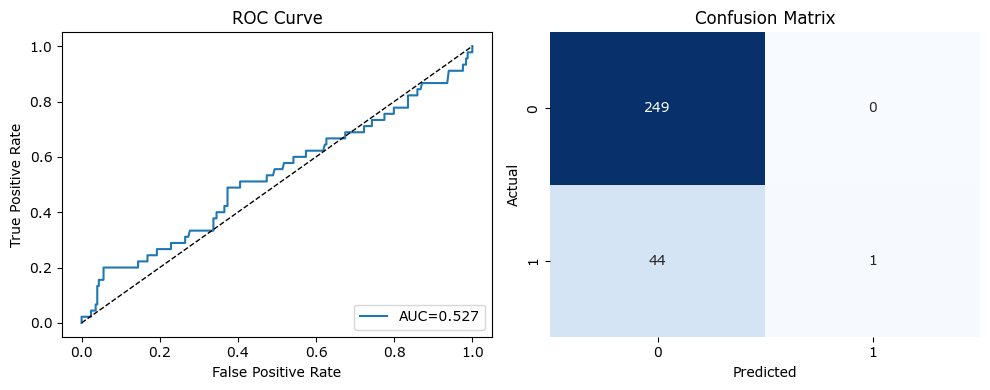

In [94]:
# 이미 계산한 것 재사용
y_true = y_test
y_pred_prob = y_pred_proba[:, 1]

# 임계값 0.59로 평가 (원래 쓰던 값)
results = eval_binary_classifier(y_true, y_pred_prob, threshold=0.59)

# 분류모델에서의 지표 계산 방법
```
1. macro avg (단순 평균)

각 클래스의 precision, recall, f1-score를 동등 가중치로 평균낸 값

클래스별 표본 개수(비율) 무시 → 소수 클래스도 동일한 비중

불균형 데이터에서 소수 클래스 성능에 민감함

계산 예시 (Recall 기준)

recall(0) = 1.00
recall(1) = 0.02
macro recall = (1.00 + 0.02) / 2 = 0.51

2. weighted avg (가중 평균)

각 클래스 지표를 그 클래스 표본 개수 비율로 가중 평균

데이터 불균형 영향을 받음 → 표본이 많은 클래스의 성능이 높으면 이 값도 높아짐

전체 데이터 정확도와 비슷한 경향을 보임

계산 예시 (Recall 기준)

recall(0) = 1.00 (249개)
recall(1) = 0.02 (45개)

weighted recall = (1.00*249 + 0.02*45) / (249+45)
                = (249 + 0.9) / 294
                ≈ 0.85

정리
평균 방식	표본 수 반영	특징
macro avg	❌	클래스별 성능 차이를 공평하게 반영, 소수 클래스 성능 나쁠 때 확 떨어짐
weighted avg	✅	표본 많은 클래스 영향 큼, 전체 성능에 가깝게 나옴
```